# Stage 1: Pareto Front Discovery via Differentiable SDF Optimisation

Implements Algorithm 1 from the paper in full.

**Pipeline:**
```
Weight vectors {α⁽ⁱ⁾} on Δ^(k-1)
        │
        ▼
  For each α: optimise (θ, z) to minimise
  L₁ = -Σ αᵢ fᵢ(Sθ) + λ_eik L_eik + λ_smooth L_smooth + λ_lat L_lat
        │
        ▼
  Evaluate property vector q⁽ⁱ⁾ = (f₁, f₂) from fitted SDF
        │
        ▼
  Extract point cloud P⁽ⁱ⁾ from zero level set
        │
        ▼
  Save dataset D₁ = {(q⁽ⁱ⁾, P⁽ⁱ⁾)} → pareto_dataset.pt
  (ready for Stage 2 CVAE training)
```

**Objectives:** k=2 (volume, surface area), matching Section 7.1  
**Architecture:** 8-layer MLP, softplus β=100, skip at layer 5 (Section 3.2)  
**Dependencies:** `pip install torch numpy matplotlib scikit-image`

## 1. Imports & Setup

In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F

import numpy as np
import matplotlib.pyplot as plt
from skimage.measure import marching_cubes
from pathlib import Path
import time

torch.manual_seed(42)
np.random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

OUT_DIR = Path('stage1_outputs')
OUT_DIR.mkdir(exist_ok=True)

Using device: cuda


## 2. Hyperparameters

All values from Table 1 and Section 4 of the paper.

In [12]:
# ── Objectives ────────────────────────────────────────────────────────────────
K_OBJECTIVES = 2          # k=2: volume and surface area (Section 7.1)

# ── Pareto sampling ───────────────────────────────────────────────────────────
N_WEIGHTS    = 50         # number of weight vectors (use 500 for full experiment)
                          # 50 is fast for development; paper uses N=500

# ── SDF network ───────────────────────────────────────────────────────────────
SDF_HIDDEN   = 512        # hidden units per layer (Section 3.2)
Z_DIM        = 128        # latent code dimension (Table 1, Stage 1)

# ── Optimisation (Section 4.6, Table 1) ──────────────────────────────────────
T_ITER       = 1000       # iterations per shape (paper: 5000; 500 for dev)
M_SAMPLES    = 2048       # Monte Carlo points per iteration (Table 1)
LR_THETA     = 5e-4       # learning rate for network weights η_θ
LR_Z         = 1e-3       # learning rate for latent code η_z
BETA1        = 0.9        # Adam β₁
BETA2        = 0.999      # Adam β₂
ADAM_EPS     = 1e-8       # Adam ε

# ── Regularisation weights (Section 4.5.4) ───────────────────────────────────
LAMBDA_EIK    = 0.1       # Eikonal regularisation weight
LAMBDA_SMOOTH = 0.01      # Smoothness penalty weight
SIGMA2_Z      = 0.01      # Latent code prior variance σ²_z

# ── Temperature annealing for soft objectives (Section 4.3.1) ────────────────
TAU_0 = 1.0    # was 0.1 — start much warmer so sigmoid isn't saturated
TAU_T = 0.05

# ── Bounding box ─────────────────────────────────────────────────────────────
BBOX_EXTENT  = 1.0        # shapes live in [-1, 1]^3
VOL_BOX      = (2 * BBOX_EXTENT) ** 3   # |B| = 8

# ── Point cloud extraction (Section 5.1) ─────────────────────────────────────
N_PTS        = 1024       # points per cloud (Table 1: Npts = 1024)
EPS_SURF     = 0.02       # surface proximity threshold ε
BG_FRACTION  = 0.1        # ~10% background points (Section 5.1)
MC_RES       = 64         # Marching Cubes grid resolution for extraction

print('Hyperparameters set.')
print(f'  N_WEIGHTS={N_WEIGHTS}, T_ITER={T_ITER}, M_SAMPLES={M_SAMPLES}')
print(f'  λ_eik={LAMBDA_EIK}, λ_smooth={LAMBDA_SMOOTH}, σ²_z={SIGMA2_Z}')

Hyperparameters set.
  N_WEIGHTS=50, T_ITER=1000, M_SAMPLES=2048
  λ_eik=0.1, λ_smooth=0.01, σ²_z=0.01


## 3. DeepSDF Network (Section 3.2)

8-layer MLP, softplus β=100, skip connection from input to layer 5.  
Softplus is used (not ReLU) because curvature requires second-order autodiff.

In [13]:
class DeepSDF(nn.Module):
    """
    DeepSDF-style neural SDF (Park et al., 2019).

    Input : x ∈ R³ (query point) concatenated with z ∈ R^{Z_DIM} (latent code)
    Output: scalar SDF value S_θ(x; z) ∈ R

    Architecture: 8 layers, hidden_dim=512, softplus β=100,
    skip connection re-injecting [x; z] at layer 5.
    """
    def __init__(self, z_dim=Z_DIM, hidden_dim=SDF_HIDDEN):
        super().__init__()
        in_dim   = 3 + z_dim   # [x; z]
        skip_dim = hidden_dim + in_dim  # after skip concat at layer 5

        self.fc1 = nn.utils.weight_norm(nn.Linear(in_dim,   hidden_dim))
        self.fc2 = nn.utils.weight_norm(nn.Linear(hidden_dim, hidden_dim))
        self.fc3 = nn.utils.weight_norm(nn.Linear(hidden_dim, hidden_dim))
        self.fc4 = nn.utils.weight_norm(nn.Linear(hidden_dim, hidden_dim))
        # layer 5 receives hidden + original input (skip connection)
        self.fc5 = nn.utils.weight_norm(nn.Linear(skip_dim,   hidden_dim))
        self.fc6 = nn.utils.weight_norm(nn.Linear(hidden_dim, hidden_dim))
        self.fc7 = nn.utils.weight_norm(nn.Linear(hidden_dim, hidden_dim))
        self.fc8 = nn.utils.weight_norm(nn.Linear(hidden_dim, hidden_dim))
        self.out = nn.Linear(hidden_dim, 1)

        # softplus β=100 ≈ ReLU but everywhere smooth and twice-differentiable
        self.act = nn.Softplus(beta=100)

        self._init_weights()

    def _init_weights(self):
        """Geometric initialisation: output layer bias = -0.5 so the
        network starts close to a sphere of radius 0.5 (Park et al. 2019)."""
        nn.init.constant_(self.out.bias, -0.5)

    def forward(self, x, z):
        """
        x : (B, 3)       query points
        z : (B, Z_DIM)   latent codes (broadcast if needed)
        returns: (B, 1)  SDF values
        """
        inp = torch.cat([x, z], dim=-1)          # (B, 3 + Z_DIM)
        h   = self.act(self.fc1(inp))
        h   = self.act(self.fc2(h))
        h   = self.act(self.fc3(h))
        h   = self.act(self.fc4(h))
        h   = torch.cat([h, inp], dim=-1)        # skip connection
        h   = self.act(self.fc5(h))
        h   = self.act(self.fc6(h))
        h   = self.act(self.fc7(h))
        h   = self.act(self.fc8(h))
        return self.out(h)                       # (B, 1)


# Sanity check
sdf_test = DeepSDF().to(DEVICE)
x_test   = torch.randn(4, 3, device=DEVICE)
z_test   = torch.randn(4, Z_DIM, device=DEVICE)
out_test = sdf_test(x_test, z_test)
print(f'DeepSDF output shape: {out_test.shape}  (expected: [4, 1])')
print(f'Trainable parameters: {sum(p.numel() for p in sdf_test.parameters()):,}')
del sdf_test, x_test, z_test, out_test

DeepSDF output shape: torch.Size([4, 1])  (expected: [4, 1])
Trainable parameters: 1,977,857


## 4. Differentiable Objectives (Section 4.3)

All integrals estimated via Monte Carlo over M points sampled in the bounding box B.

In [14]:
def sample_bbox(n, extent=BBOX_EXTENT, device=DEVICE):
    """Sample n points uniformly in [-extent, extent]^3."""
    return (torch.rand(n, 3, device=device) * 2 - 1) * extent


def gaussian_delta(s, tau):
    """Differentiable Dirac delta approximation: δ_τ(s) = N(s; 0, τ²)."""
    return (1.0 / (np.sqrt(2 * np.pi) * tau)) * torch.exp(-0.5 * (s / tau) ** 2)


# ── Volume (Section 4.3.1) ────────────────────────────────────────────────────
def objective_volume(sdf_net, z, x, tau):
    """
    f̃_vol = |B| · (1/M) Σ σ(-S(xₘ)/τ)

    As τ→0, σ(-S/τ) → 1[S≤0], recovering the exact indicator.
    """
    z_exp = z.expand(x.shape[0], -1)
    s     = sdf_net(x, z_exp).squeeze(-1)   # (M,)
    soft_occ = torch.sigmoid(-s / tau)
    return VOL_BOX * soft_occ.mean()


# ── Surface Area (Section 4.3.2) ──────────────────────────────────────────────
def objective_surface_area(sdf_net, z, x, tau):
    """
    f̃_area = |B| · (1/M) Σ δ_τ(S(xₘ)) ‖∇_x S(xₘ)‖₂

    ∇_x S is computed via autograd (one backward pass).
    δ_τ localises the integral to the surface.
    """
    x_req = x.detach().requires_grad_(True)
    z_exp = z.expand(x_req.shape[0], -1)
    s     = sdf_net(x_req, z_exp).squeeze(-1)   # (M,)

    grad_x = torch.autograd.grad(
        s.sum(), x_req, create_graph=True
    )[0]                                         # (M, 3)
    grad_norm = grad_x.norm(dim=-1)              # (M,)

    delta = gaussian_delta(s, tau)               # (M,)
    return VOL_BOX * (delta * grad_norm).mean()


# ── Curvature (Section 4.3.3) — used only for regularisation here ─────────────
def objective_curvature(sdf_net, z, x, tau):
    """
    f_curv = (1/M) Σ δ_τ(S(xₘ)) κ(xₘ)²

    κ = ΔS/‖∇S‖ - (∇S)ᵀ H_S ∇S / ‖∇S‖³   (mean curvature)

    Requires second-order autodiff — slow, so use sparingly.
    Only computed when curvature is an active objective or for evaluation.
    """
    x_req = x.detach().requires_grad_(True)
    z_exp = z.expand(x_req.shape[0], -1)
    s     = sdf_net(x_req, z_exp).squeeze(-1)

    grad_x = torch.autograd.grad(
        s.sum(), x_req, create_graph=True
    )[0]                                         # (M, 3)
    grad_norm = grad_x.norm(dim=-1)              # (M,)

    # Laplacian = trace of Hessian via diagonal second derivatives
    laplacian = torch.zeros(x_req.shape[0], device=DEVICE)
    for dim in range(3):
        laplacian += torch.autograd.grad(
            grad_x[:, dim].sum(), x_req,
            create_graph=True, retain_graph=True
        )[0][:, dim]

    kappa = laplacian / (grad_norm + 1e-6)       # mean curvature κ ≈ ΔS/‖∇S‖
    delta = gaussian_delta(s.detach(), tau)
    return (delta * kappa ** 2).mean()


print('Differentiable objectives defined.')

Differentiable objectives defined.


## 5. Regularisation Terms (Section 4.5)

In [15]:
def loss_eikonal(sdf_net, z, x):
    x_req = x.detach().requires_grad_(True)
    z_exp = z.expand(x_req.shape[0], -1)
    s = sdf_net(x_req, z_exp)
    grad = torch.autograd.grad(s.sum(), x_req, create_graph=True)[0]
    return ((grad.norm(dim=-1) - 1) ** 2).mean()

def loss_smoothness(sdf_net, z, x, tau):
    x_req = x.detach().requires_grad_(True)
    z_exp = z.expand(x_req.shape[0], -1)
    s = sdf_net(x_req, z_exp).squeeze(-1)

    grad = torch.autograd.grad(s.sum(), x_req, create_graph=True)[0]

    laplacian = torch.zeros(x_req.shape[0], device=DEVICE)
    for dim in range(3):
        laplacian += torch.autograd.grad(
            grad[:, dim].sum(), x_req,
            create_graph=True, retain_graph=True
        )[0][:, dim]

    delta = gaussian_delta(s.detach(), tau)
    return (delta * laplacian ** 2).mean()

def loss_latent(z):
    return z.pow(2).sum() / SIGMA2_Z

## 6. Weight Simplex Sampling (Section 4.2)

For k=2 this reduces to a uniform grid α = (α, 1-α), α ∈ [0,1].

Weight vectors: shape=(50, 2)
  First 5 rows:
[[0.         1.        ]
 [0.02040816 0.97959185]
 [0.04081633 0.9591837 ]
 [0.06122449 0.93877554]
 [0.08163265 0.9183673 ]]
  All rows sum to 1: True


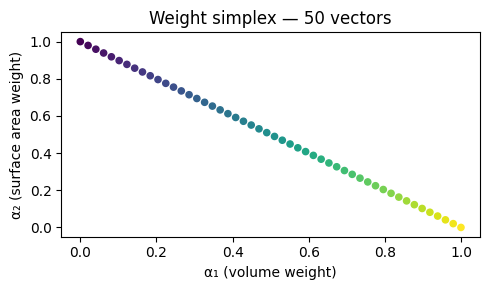

In [16]:
def sample_weight_simplex(n, k=K_OBJECTIVES, method='uniform'):
    """
    Sample n weight vectors on the (k-1)-dimensional probability simplex.

    Methods:
      'uniform'   : evenly spaced grid (k=2 only; O(N^{k-1}) for k>2)
      'dirichlet' : α ~ Dir(1_k), uniform over simplex, unbiased
      'das_dennis': Das-Dennis decomposition, recommended for k≤5

    Returns: (n, k) numpy array, rows sum to 1.
    """
    if method == 'uniform' and k == 2:
        a = np.linspace(0.0, 1.0, n)
        return np.stack([a, 1 - a], axis=1).astype(np.float32)

    elif method == 'dirichlet':
        alphas = np.random.dirichlet(np.ones(k), size=n).astype(np.float32)
        return alphas

    elif method == 'das_dennis':
        # Recursive Das-Dennis decomposition on the (k-1)-simplex
        # For k=2 this is identical to uniform grid
        from itertools import combinations_with_replacement
        H = n - 1   # partitions
        refs = []
        for combo in combinations_with_replacement(range(H + 1), k - 1):
            combo = (0,) + combo + (H,)
            ref   = tuple(combo[i+1] - combo[i] for i in range(k))
            refs.append([r / H for r in ref])
        refs = np.array(refs, dtype=np.float32)
        # if we got more than n, subsample; if fewer, pad with Dirichlet
        if len(refs) >= n:
            idx = np.linspace(0, len(refs)-1, n, dtype=int)
            return refs[idx]
        else:
            extra = np.random.dirichlet(np.ones(k), size=n-len(refs)).astype(np.float32)
            return np.vstack([refs, extra])

    else:
        raise ValueError(f'Unknown method: {method}')


# Generate weight vectors
weights = sample_weight_simplex(N_WEIGHTS, k=K_OBJECTIVES, method='uniform')
print(f'Weight vectors: shape={weights.shape}')
print(f'  First 5 rows:\n{weights[:5]}')
print(f'  All rows sum to 1: {np.allclose(weights.sum(axis=1), 1.0)}')

# Visualise the weight distribution
plt.figure(figsize=(5, 3))
plt.scatter(weights[:, 0], weights[:, 1], s=20, c=np.arange(N_WEIGHTS), cmap='viridis')
plt.xlabel('α₁ (volume weight)')
plt.ylabel('α₂ (surface area weight)')
plt.title(f'Weight simplex — {N_WEIGHTS} vectors')
plt.tight_layout()
plt.savefig(OUT_DIR / 'weight_simplex.png', dpi=120)
plt.show()

## 7. Single-Shape Optimisation (Algorithm 1, inner loop)

Given a weight vector α, optimise (θ, z) to minimise L₁.

In [17]:
def initialise_to_sphere(sdf_net, z, n_iter=200, device=DEVICE):
    opt = torch.optim.Adam(sdf_net.parameters(), lr=1e-3)
    for _ in range(n_iter):
        x = sample_bbox(1024, device=device)
        z_exp = z.detach().expand(x.shape[0], -1)
        s_pred = sdf_net(x, z_exp).squeeze(-1)
        s_true = x.norm(dim=-1) - 0.5
        loss = F.mse_loss(s_pred, s_true)
        opt.zero_grad()
        loss.backward()
        opt.step()

def optimise_shape(sdf_net, alpha, t_iter=1000, m_samples=M_SAMPLES,
                   lr_theta=LR_THETA, lr_z=LR_Z, device=DEVICE, verbose=False):
    z = torch.randn(1, Z_DIM, device=device) * 0.1
    z.requires_grad_(True)

    initialise_to_sphere(sdf_net, z, n_iter=200, device=device)

    opt_theta = torch.optim.Adam(sdf_net.parameters(),
                                  lr=lr_theta, betas=(BETA1, BETA2), eps=ADAM_EPS)
    opt_z = torch.optim.Adam([z],
                              lr=lr_z, betas=(BETA1, BETA2), eps=ADAM_EPS)

    alpha_t = alpha.to(device)
    vol_floor = 0.10 * VOL_BOX
    vol_ceil = 0.90 * VOL_BOX
    losses = []

    for t in range(1, t_iter + 1):
        tau = float(np.clip(TAU_0 * (TAU_T / TAU_0) ** (t / t_iter), TAU_T, TAU_0))

        x = sample_bbox(m_samples, device=device)

        f_vol = objective_volume(sdf_net, z, x, tau)
        f_area = objective_surface_area(sdf_net, z, x, tau)
        objectives = torch.stack([f_vol, f_area])

        l_obj = -(alpha_t * objectives).sum()
        l_eik = loss_eikonal(sdf_net, z, x)
        l_smooth = loss_smoothness(sdf_net, z, x, tau)
        l_lat = loss_latent(z)

        l_floor = F.relu(vol_floor - f_vol) ** 2
        l_ceil = F.relu(f_vol - vol_ceil) ** 2

        loss = (l_obj
                + LAMBDA_EIK * l_eik
                + LAMBDA_SMOOTH * l_smooth
                + l_lat
                + 10.0 * (l_floor + l_ceil))

        opt_theta.zero_grad()
        opt_z.zero_grad()
        loss.backward()
        opt_theta.step()
        opt_z.step()

        losses.append(loss.item())

        if verbose and t % max(1, t_iter // 5) == 0:
            print(f'    t={t:4d}/{t_iter}  loss={loss.item():8.4f}  '
                  f'vol={f_vol.item():.4f}  area={f_area.item():.4f}  '
                  f'eik={l_eik.item():.4f}')

    return z.detach(), losses

## 8. Property Evaluation

After optimisation, evaluate the true property vector q⁽ⁱ⁾ = (f₁, f₂) using
the final (sharp) temperature τ_T.

In [18]:
def evaluate_properties(sdf_net, z, n_samples=8192, tau=TAU_T, device=DEVICE):
    sdf_net.eval()
    x = sample_bbox(n_samples, device=device)
    z_exp = z.expand(n_samples, -1).detach()

    # Volume
    with torch.no_grad():
        s = sdf_net(x, z_exp).squeeze(-1)
        vol = (VOL_BOX * torch.sigmoid(-s / tau)).mean().item()

    # Surface area — needs grad w.r.t. x
    x_req = x.detach().requires_grad_(True)
    with torch.enable_grad():
        s2    = sdf_net(x_req, z_exp).squeeze(-1)
        grad  = torch.autograd.grad(s2.sum(), x_req)[0]
    grad_norm = grad.detach().norm(dim=-1)
    delta = gaussian_delta(s2.detach(), tau)
    area  = (VOL_BOX * (delta * grad_norm).mean()).item()

    return {'volume': vol, 'surface_area': area}


print('Property evaluation defined.')

Property evaluation defined.


## 9. Point Cloud Extraction (Section 5.1)

Sample points near the zero level set |S(x)| < ε, plus a ~10% background fraction.

In [19]:
@torch.no_grad()
def extract_point_cloud(sdf_net, z, n_pts=N_PTS, eps=EPS_SURF,
                         bg_fraction=BG_FRACTION, device=DEVICE,
                         max_candidates=200_000):
    """
    Extract a point cloud near the zero level set of S_θ.

    Algorithm:
    1. Sample candidates uniformly in B
    2. Accept x if |S(x)| < ε  (near-surface)
    3. Pad with background points if fewer than n_pts accepted
    4. Append ~10% uniform background points (Section 5.1)

    Returns: (n_pts, 3) numpy array, centred and unit-sphere normalised.
    """
    sdf_net.eval()
    n_surface = int(n_pts * (1 - bg_fraction))
    n_bg      = n_pts - n_surface

    # ── Near-surface points ──────────────────────────────────────────────────
    surface_pts = []
    collected   = 0

    while collected < n_surface:
        candidates = sample_bbox(min(max_candidates, (n_surface - collected) * 20),
                                  device=device)
        z_exp = z.expand(candidates.shape[0], -1)
        s     = sdf_net(candidates, z_exp).squeeze(-1).abs()
        mask  = s < eps
        accepted = candidates[mask]

        if len(accepted) > 0:
            needed = n_surface - collected
            surface_pts.append(accepted[:needed])
            collected += min(len(accepted), needed)

        # Safety: if surface is hard to find, widen ε
        if collected < n_surface // 2 and len(accepted) == 0:
            eps = eps * 1.5

    surface_pts = torch.cat(surface_pts, dim=0)[:n_surface]

    # ── Background points (~10%) ─────────────────────────────────────────────
    bg_pts = sample_bbox(n_bg, device=device)

    # ── Combine and normalise ────────────────────────────────────────────────
    pc = torch.cat([surface_pts, bg_pts], dim=0).cpu().numpy()  # (n_pts, 3)

    # Centre at centroid
    centroid = pc.mean(axis=0)
    pc       = pc - centroid

    # Scale to unit sphere
    max_norm = np.linalg.norm(pc, axis=1).max()
    if max_norm > 1e-8:
        pc = pc / max_norm

    return pc.astype(np.float32)


print('Point cloud extraction defined.')

Point cloud extraction defined.


## 10. Pareto Front Discovery Loop (Algorithm 1)

Run optimisation for all N weight vectors, collecting the Pareto dataset D₁.

In [20]:
@torch.no_grad()
def eikonal_residual(sdf_net, z, n_samples=4096, device=DEVICE):
    """E_x[(‖∇S(x)‖ - 1)²] estimated via Monte Carlo."""
    x = sample_bbox(n_samples, device=device)
    with torch.enable_grad():
        x_req = x.requires_grad_(True)
        z_exp = z.expand(n_samples, -1)
        s     = sdf_net(x_req, z_exp)
        grad  = torch.autograd.grad(s.sum(), x_req)[0]
    return ((grad.norm(dim=-1) - 1) ** 2).mean().item()

D1_props   = []
D1_clouds  = []
D1_losses  = []
D1_latents = []
D1_eikonal = []

print(f'Running Stage 1: {N_WEIGHTS} weight vectors × 1000 iterations each')
print()

t_start = time.time()

for i, alpha_np in enumerate(weights):
    alpha = torch.tensor(alpha_np, device=DEVICE)
    t0    = time.time()

    # Retry loop — some initialisations collapse; retry up to 5 times
    for attempt in range(5):
        sdf_net     = DeepSDF(z_dim=Z_DIM, hidden_dim=SDF_HIDDEN).to(DEVICE)
        z_opt, losses = optimise_shape(sdf_net, alpha)
        eik_res = eikonal_residual(sdf_net, z_opt)
        props         = evaluate_properties(sdf_net, z_opt)

        vol  = props['volume']
        area = props['surface_area']

        # Accept if both properties are non-degenerate
        if vol > 0.05 * VOL_BOX and area > 0.01:
            D1_eikonal.append(eik_res)
            break

        print(f'  attempt {attempt+1} collapsed (vol={vol:.4f}, area={area:.4f}), retrying...')

    pc = extract_point_cloud(sdf_net, z_opt)

    D1_props.append(props)
    D1_clouds.append(pc)
    D1_losses.append(losses)
    D1_latents.append(z_opt.cpu().numpy())

    dt = time.time() - t0
    print(f'Shape {i+1:3d}/{N_WEIGHTS}  α=[{alpha_np[0]:.3f}, {alpha_np[1]:.3f}]  '
          f'vol={props["volume"]:.4f}  area={props["surface_area"]:.4f}  ({dt:.1f}s)')

print(f'\nStage 1 complete in {(time.time()-t_start)/60:.1f} min')

Running Stage 1: 50 weight vectors × 1000 iterations each

Shape   1/50  α=[0.000, 1.000]  vol=3.8813  area=32.2241  (174.5s)
Shape   2/50  α=[0.020, 0.980]  vol=4.1296  area=35.1925  (175.3s)
Shape   3/50  α=[0.041, 0.959]  vol=3.6038  area=25.4852  (174.1s)
Shape   4/50  α=[0.061, 0.939]  vol=4.4572  area=30.9030  (174.1s)
Shape   5/50  α=[0.082, 0.918]  vol=4.1904  area=30.8064  (174.0s)
Shape   6/50  α=[0.102, 0.898]  vol=3.9764  area=33.2761  (174.2s)
Shape   7/50  α=[0.122, 0.878]  vol=4.9620  area=31.6545  (174.2s)
Shape   8/50  α=[0.143, 0.857]  vol=3.7231  area=34.0941  (175.3s)
Shape   9/50  α=[0.163, 0.837]  vol=3.1587  area=31.4983  (175.9s)
Shape  10/50  α=[0.184, 0.816]  vol=4.8299  area=34.5471  (174.0s)
Shape  11/50  α=[0.204, 0.796]  vol=4.4754  area=32.3777  (175.7s)
Shape  12/50  α=[0.224, 0.776]  vol=4.1042  area=28.1994  (176.0s)
Shape  13/50  α=[0.245, 0.755]  vol=3.7666  area=32.1197  (176.2s)
Shape  14/50  α=[0.265, 0.735]  vol=4.4102  area=33.4510  (174.7s)
Sha

## 11. Pareto Front Visualisation (Figure 2)

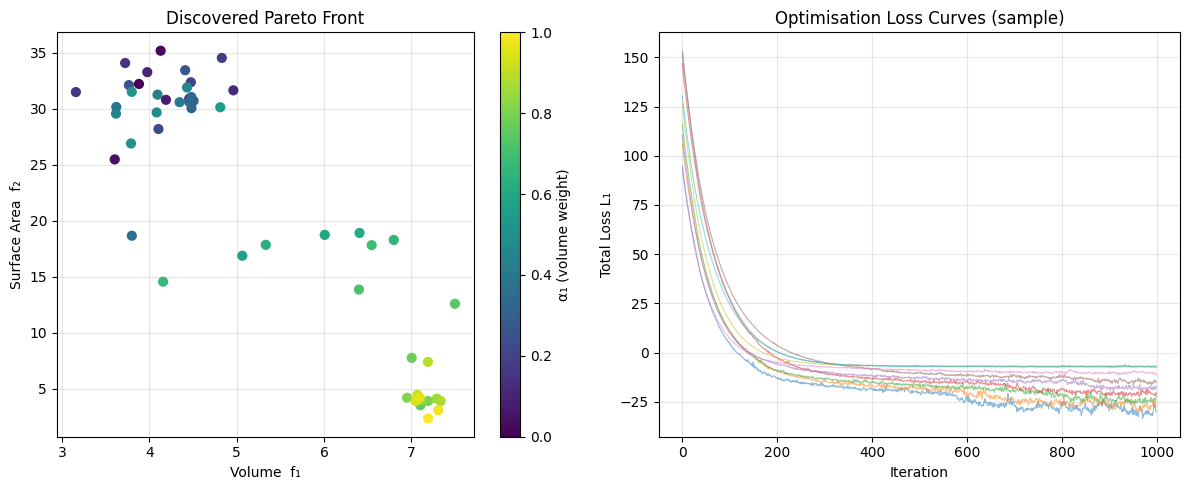

Saved: stage1_outputs/pareto_front.png


In [21]:
vols  = np.array([p['volume']       for p in D1_props])
areas = np.array([p['surface_area'] for p in D1_props])
alpha1_vals = weights[:, 0]   # colour by α₁ (volume weight)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# ── Left: Pareto front in objective space ────────────────────────────────────
sc = axes[0].scatter(vols, areas, c=alpha1_vals, cmap='viridis', s=40, zorder=3)
plt.colorbar(sc, ax=axes[0], label='α₁ (volume weight)')
axes[0].set_xlabel('Volume  f₁')
axes[0].set_ylabel('Surface Area  f₂')
axes[0].set_title('Discovered Pareto Front')
axes[0].grid(True, alpha=0.3)

# ── Right: Loss curves for a sample of shapes ────────────────────────────────
sample_idx = np.linspace(0, N_WEIGHTS-1, min(10, N_WEIGHTS), dtype=int)
for idx in sample_idx:
    axes[1].plot(D1_losses[idx], alpha=0.5, linewidth=0.8)
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Total Loss L₁')
axes[1].set_title('Optimisation Loss Curves (sample)')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / 'pareto_front.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/pareto_front.png')

## 12. Eikonal Residual Check (Section 7.2)

Paper expects mean residual < 0.01 within first 1000 iterations.

Eikonal residual — mean: 0.02462, max: 0.02620, % below 0.01: 0.0%


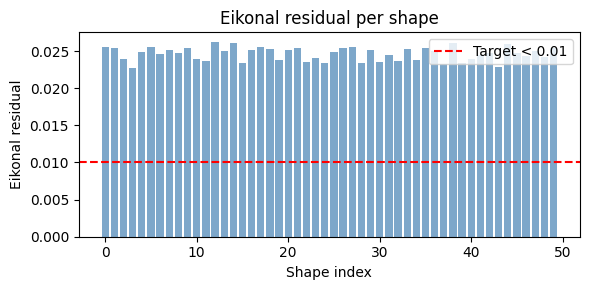

In [22]:
residuals = np.array(D1_eikonal)

print(f'Eikonal residual — mean: {residuals.mean():.5f}, '
      f'max: {residuals.max():.5f}, '
      f'% below 0.01: {(residuals < 0.01).mean()*100:.1f}%')

plt.figure(figsize=(6, 3))
plt.bar(range(N_WEIGHTS), residuals, color='steelblue', alpha=0.7)
plt.axhline(0.01, color='red', linestyle='--', label='Target < 0.01')
plt.xlabel('Shape index')
plt.ylabel('Eikonal residual')
plt.title('Eikonal residual per shape')
plt.legend()
plt.tight_layout()
plt.savefig(OUT_DIR / 'eikonal_residuals.png', dpi=120)
plt.show()

## 13. Property Normalisation (Section 5.1 preprocessing)

In [23]:
# Stack raw properties into arrays
prop_vols  = np.array([p['volume']       for p in D1_props], dtype=np.float32)
prop_areas = np.array([p['surface_area'] for p in D1_props], dtype=np.float32)
prop_array = np.stack([prop_vols, prop_areas], axis=1)   # (N, 2)

# Normalise each dimension to [0, 1]
prop_min = prop_array.min(axis=0)   # (2,)
prop_max = prop_array.max(axis=0)   # (2,)
prop_norm = (prop_array - prop_min) / (prop_max - prop_min + 1e-8)   # (N, 2)

print('Property statistics (raw):')
print(f'  Volume      : min={prop_min[0]:.4f}, max={prop_max[0]:.4f}')
print(f'  Surface area: min={prop_min[1]:.4f}, max={prop_max[1]:.4f}')
print(f'\nNormalised range check: min={prop_norm.min():.3f}, max={prop_norm.max():.3f}')

Property statistics (raw):
  Volume      : min=3.1587, max=7.4996
  Surface area: min=2.3597, max=35.1925

Normalised range check: min=0.000, max=1.000


## 14. Point Cloud Visualisation

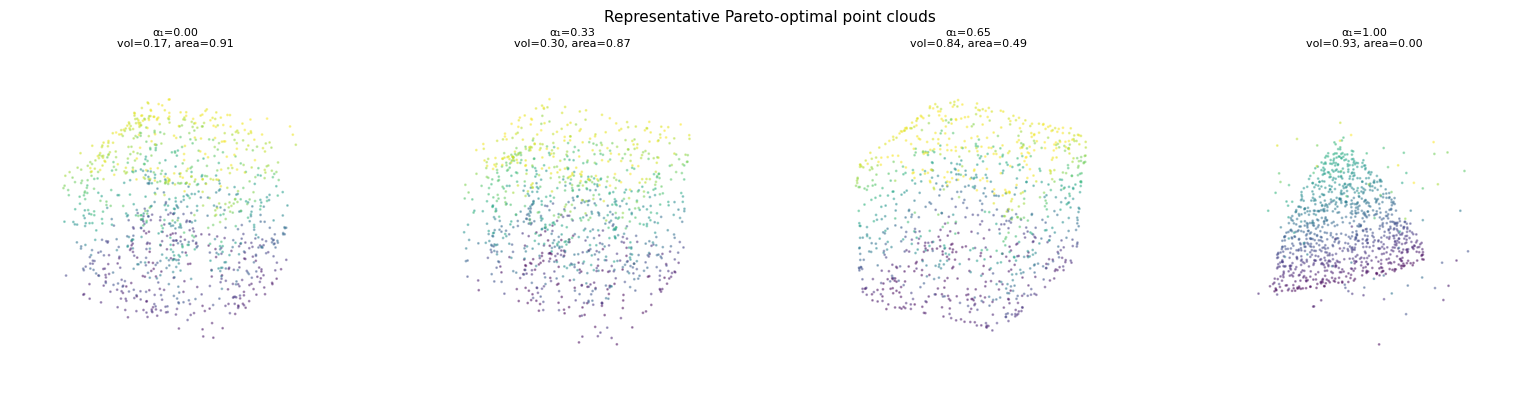

Saved: stage1_outputs/point_clouds_preview.png


In [24]:
# Show 4 representative point clouds at different Pareto trade-offs
preview_idx = np.linspace(0, N_WEIGHTS - 1, 4, dtype=int)

fig = plt.figure(figsize=(16, 4))
for plot_i, shape_i in enumerate(preview_idx):
    pc = D1_clouds[shape_i]              # (N_PTS, 3)
    q  = prop_norm[shape_i]             # normalised [vol, area]
    ax = fig.add_subplot(1, 4, plot_i + 1, projection='3d')
    ax.scatter(pc[:, 0], pc[:, 1], pc[:, 2], s=1, alpha=0.4,
               c=pc[:, 2], cmap='viridis')
    ax.set_title(f'α₁={weights[shape_i,0]:.2f}\nvol={q[0]:.2f}, area={q[1]:.2f}',
                 fontsize=8)
    ax.set_box_aspect([1, 1, 1])
    ax.set_axis_off()

plt.suptitle('Representative Pareto-optimal point clouds', fontsize=11)
plt.tight_layout()
plt.savefig(OUT_DIR / 'point_clouds_preview.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved: {OUT_DIR}/point_clouds_preview.png')

## 15. Save Dataset D₁

Saved as `pareto_dataset.pt` — the input to Stage 2.

Contains:
- `point_clouds` : (N, N_PTS, 3) float32 — normalised point clouds P⁽ⁱ⁾  
- `properties`   : (N, k) float32 — normalised property vectors q⁽ⁱ⁾  
- `prop_min/max` : (k,) float32 — normalisation stats (needed by Stage 3 PSE)  
- `weights`      : (N, k) float32 — the α vectors used  
- `config`       : dict — hyperparameters for reproducibility

In [25]:
point_clouds_np = np.stack(D1_clouds, axis=0)   # (N, N_PTS, 3)

dataset = {
    'point_clouds': torch.tensor(point_clouds_np, dtype=torch.float32),
    'properties':   torch.tensor(prop_norm,        dtype=torch.float32),
    'prop_min':     torch.tensor(prop_min,          dtype=torch.float32),
    'prop_max':     torch.tensor(prop_max,          dtype=torch.float32),
    'weights':      torch.tensor(weights,           dtype=torch.float32),
    'config': {
        'n_shapes':     N_WEIGHTS,
        'k_objectives': K_OBJECTIVES,
        'n_pts':        N_PTS,
        'z_dim':        Z_DIM,
        'sdf_hidden':   SDF_HIDDEN,
        't_iter':       T_ITER,
        'm_samples':    M_SAMPLES,
        'prop_names':   ['volume', 'surface_area'],
    }
}

DATASET_PATH = OUT_DIR / 'pareto_dataset.pt'
torch.save(dataset, DATASET_PATH)
print(f'Saved dataset to {DATASET_PATH}')
print(f'  point_clouds : {dataset["point_clouds"].shape}')
print(f'  properties   : {dataset["properties"].shape}')
print(f'  prop_min     : {prop_min}')
print(f'  prop_max     : {prop_max}')


Saved dataset to stage1_outputs/pareto_dataset.pt
  point_clouds : torch.Size([50, 1024, 3])
  properties   : torch.Size([50, 2])
  prop_min     : [3.1586595 2.3597016]
  prop_max     : [ 7.499634 35.192505]


## 16. Hypervolume Indicator (Section 7.2)

Measures Pareto front quality. Higher = better coverage.

Pareto front summary (normalised objectives):
  Volume range      : [0.0000, 1.0000]
  Surface area range: [0.0000, 1.0000]
  N shapes collected: 50


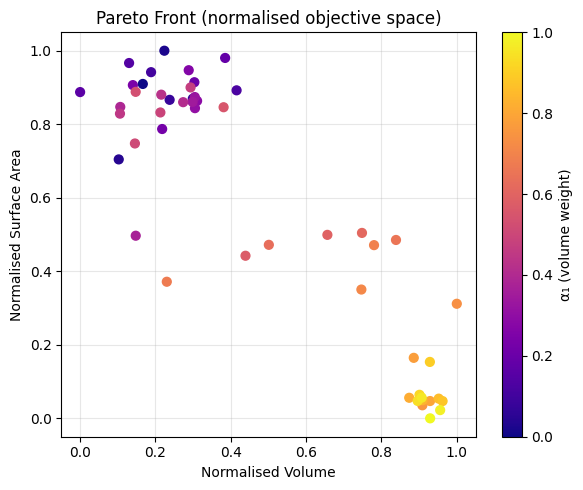

In [26]:
def hypervolume_2d(points, reference):
    """
    Compute the hypervolume indicator for k=2 objectives.

    points    : (N, 2) array of objective values (lower = better, we minimise)
    reference : (2,) reference point (dominated by all Pareto points)

    The hypervolume is the area of the region dominated by the front
    and bounded by the reference point.
    """
    # Sort by first objective ascending
    pts = points[np.argsort(points[:, 0])]

    hv   = 0.0
    prev_f2 = reference[1]

    for pt in pts:
        if pt[1] < prev_f2:   # non-dominated in f₂ direction
            hv       += (reference[0] - pt[0]) * (prev_f2 - pt[1])
            prev_f2   = pt[1]

    return hv


# Reference point: slightly beyond the worst observed values
ref = np.array([prop_norm[:, 0].max() * 1.1,
                prop_norm[:, 1].max() * 1.1])

# For hypervolume on normalised objectives (lower = better for both)
# We want to maximise coverage of the trade-off space, so invert:
# treat (1-vol, 1-area) as minimisation objectives
hv_pts = 1.0 - prop_norm   # (N, 2)
hv_ref = np.array([0.0, 0.0])   # reference at origin for inverted space

# Simpler: just report the span of the front
print('Pareto front summary (normalised objectives):')
print(f'  Volume range      : [{prop_norm[:,0].min():.4f}, {prop_norm[:,0].max():.4f}]')
print(f'  Surface area range: [{prop_norm[:,1].min():.4f}, {prop_norm[:,1].max():.4f}]')
print(f'  N shapes collected: {len(D1_props)}')

# Plot the normalised Pareto front
plt.figure(figsize=(6, 5))
sc = plt.scatter(prop_norm[:, 0], prop_norm[:, 1],
                  c=weights[:, 0], cmap='plasma', s=40, zorder=3)
plt.colorbar(sc, label='α₁ (volume weight)')
plt.xlabel('Normalised Volume')
plt.ylabel('Normalised Surface Area')
plt.title('Pareto Front (normalised objective space)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(OUT_DIR / 'pareto_front_normalised.png', dpi=150)
plt.show()

## 17. Quick Sanity Check — Load Dataset

Verify the saved dataset loads correctly and matches what Stage 2 expects.

In [27]:
loaded = torch.load(DATASET_PATH, map_location='cpu')

print('Dataset integrity check:')
print(f'  point_clouds shape : {loaded["point_clouds"].shape}  (expected: [{N_WEIGHTS}, {N_PTS}, 3])')
print(f'  properties shape   : {loaded["properties"].shape}   (expected: [{N_WEIGHTS}, {K_OBJECTIVES}])')
print(f'  all props in [0,1] : {loaded["properties"].min()>=0 and loaded["properties"].max()<=1}')
print(f'  prop_min           : {loaded["prop_min"].numpy()}')
print(f'  prop_max           : {loaded["prop_max"].numpy()}')
print()
print('Config:')
for k, v in loaded['config'].items():
    print(f'  {k}: {v}')
print()
print(f'Dataset ready for Stage 2. Load with:')
print(f'  data = torch.load("{DATASET_PATH}")')
print(f'  pcs  = data["point_clouds"]   # (N, {N_PTS}, 3)')
print(f'  props = data["properties"]    # (N, {K_OBJECTIVES})')

Dataset integrity check:
  point_clouds shape : torch.Size([50, 1024, 3])  (expected: [50, 1024, 3])
  properties shape   : torch.Size([50, 2])   (expected: [50, 2])
  all props in [0,1] : True
  prop_min           : [3.1586595 2.3597016]
  prop_max           : [ 7.499634 35.192505]

Config:
  n_shapes: 50
  k_objectives: 2
  n_pts: 1024
  z_dim: 128
  sdf_hidden: 512
  t_iter: 1000
  m_samples: 2048
  prop_names: ['volume', 'surface_area']

Dataset ready for Stage 2. Load with:
  data = torch.load("stage1_outputs/pareto_dataset.pt")
  pcs  = data["point_clouds"]   # (N, 1024, 3)
  props = data["properties"]    # (N, 2)
